In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage
import math


import scipy.cluster.hierarchy as shc

pd.set_option('display.max_columns', None)

In [4]:
def loader(id):
    if id in ['id', 'user_id']:
        df = pd.read_csv(f'data/affinity_post_{id}.csv').set_index(id)
        for col in ['1_tipoEscula', '7_idiomas', '14_etapaEducativa', '15_segLengua', '16_primLengua']:
            df[col] = df[col].apply(lambda x: eval(x) if pd.notnull(x) else np.nan)
        return df
    else:
        print('Wrong id')
        return

In [47]:
df = loader('id') # PICK DATA user_id == 97.1% lossy compression (35.0x smaller), id == 88.5% lossless compression (8.7x smaller)

C:\Users\Alex\AppData\Local\Temp\ipykernel_13728\1188995697.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'data/affinity_post_{id}.csv').set_index(id)


In [48]:
# Join language answer columns into one

def handle_nan(value):
    if isinstance(value, float) and np.isnan(value): # check is instance because np.isnan() can only evaluate floats
        return []
    else:
        return value

def get_set_fromList(row_series, col):
    if row_series[col] == []:
        return np.nan
    if isinstance(row_series[col], list):
        return list(set(row_series[col]))
    else:
        return row_series[col]

df['7_idiomas'] = df['7_idiomas'].apply(lambda x: ['Español' if i == 'Bilingüe1' else i for i in x] if x == x else np.nan)
df['15_languages'] = df[['16_primLengua', '15_segLengua', '7_idiomas']].apply(lambda row: handle_nan(row['16_primLengua']) + handle_nan(row['15_segLengua']) + handle_nan(row['7_idiomas']), axis=1)
df['15_languages'] = df.apply(lambda row_series: get_set_fromList(row_series, '15_languages'), axis=1)

In [49]:
# Drop nas, drop old language columns, fix some values
df = df.dropna(subset=['5_extraescolares', '3_comedor', '2_religioso', '4_transporte', '1_tipoEscula', '9_precioComun', '11_hombre', '6_techImportancia', '8_resultAcademicosImportancia', '13_numHijos', '14_etapaEducativa', '15_languages'])

df.drop(['7_idiomas', '16_primLengua', '15_segLengua'], axis=1, inplace=True)

df['17_country'] = df['17_country'].replace('Maroc ⵍⵎⵖⵔⵉⴱ المغرب', 'Marruecos')
df['14_etapaEducativa'] = df['14_etapaEducativa'].replace('Otros1', 'Otros')
df.loc[df['12_edad'].isna(), '12_edad'] = 'Prefiero no decirlo1'
df.loc[df['17_iso3166'].isna(), '17_iso3166'] = 'Falta-ISO'
df.loc[df['19_paraCuando'].isna(), '19_paraCuando'] = 'Falta-plazo'

### Plot the data

In [8]:
# Save non-list images
for column in ['2_religioso', '3_comedor', '4_transporte',
       '5_extraescolares', '6_techImportancia',
       '8_resultAcademicosImportancia', '9_precioMin', '9_precioComun',
       '9_precioMax', '11_hombre', '12_edad', '13_numHijos',
       '17_num_direcciones', '17_iso3166',
       '18_distanciaMin', '18_distanciaComun', '18_distanciaMax',
       '19_paraCuando']:
    plt.figure()  # Create a new figure
    df[column].hist(bins=np.arange(len(column))-.5, rwidth=0.8)  # Plot histogram
    plt.title(f'Histogram of {column}')  # Set title
    if column in ['17_iso3166', '12_edad', '19_paraCuando']:
        plt.xticks(rotation=90)
    else:
        plt.xticks(rotation=0)
    plt.xlabel(column)  # Set x-axis label
    plt.ylabel('Frequency')  # Set y-axis label
    plt.tight_layout()
    plt.savefig(f'assets/{column}_histogram.png')  # Save the figure
    plt.close()

### Create dummies

In [62]:
# Create dummy columns
df_preped = df.copy()
for col in ['1_tipoEscula', '14_etapaEducativa', '15_languages']:
    df_preped[col] = df_preped[col].apply(lambda x: ','.join(x)) # Turn into a string to get dummies
    dummies = df_preped[col].str.get_dummies(',')
    prefix = col.split('_')[0]
    dummies = dummies.add_prefix(f'{prefix}_')
    df_preped = pd.concat([df_preped, dummies], axis=1)

for col in ['12_edad', '19_paraCuando', '17_country']:
# for col in ['12_edad', '19_paraCuando', '17_iso3166']:
# for col in ['12_edad','19_paraCuando', '17_country', '17_iso3166']:   # Exclude country to avoid perfect colinearity with iso3166
    dummies = pd.get_dummies(df_preped[col]).astype(int)
    prefix = col.split('_')[0]
    dummies = dummies.add_prefix(f'{prefix}_')
    df_preped = pd.concat([df_preped, dummies], axis=1)

In [63]:
## Drop dummy-source columns and colinear features

df_preped = df_preped.drop(['1_tipoEscula', '12_edad', '14_etapaEducativa', '15_languages', '17_iso3166', '19_paraCuando'], axis=1)

# df_preped = df_preped.drop(['9_precioMin', '9_precioMax', '18_distanciaMin', '18_distanciaMax', '19_Solo estoy curioseando1', '17_country', '12_Prefiero no decirlo1', '1_Indiferente1', '17_Falta-ISO'], axis=1)
df_preped = df_preped.drop(['9_precioMin', '9_precioMax', '18_distanciaMin', '18_distanciaMax', '19_Solo estoy curioseando1', '17_country', '12_Prefiero no decirlo1', '1_Indiferente1'], axis=1)

In [65]:
# Drop na instead of impute
df_preped = df_preped.dropna(subset=['18_distanciaComun'])

In [58]:
# # Fill missing with SimpleImputer stat=median
# imputer = SimpleImputer(missing_values=np.nan, strategy='median')  # Use 5 nearest neighbors
# df_imputed = imputer.fit_transform(df_preped)
# df_preped = pd.DataFrame(df_imputed, columns=df_preped.columns)

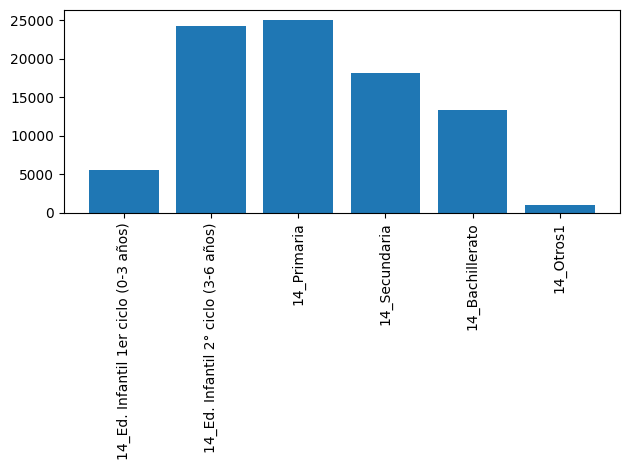

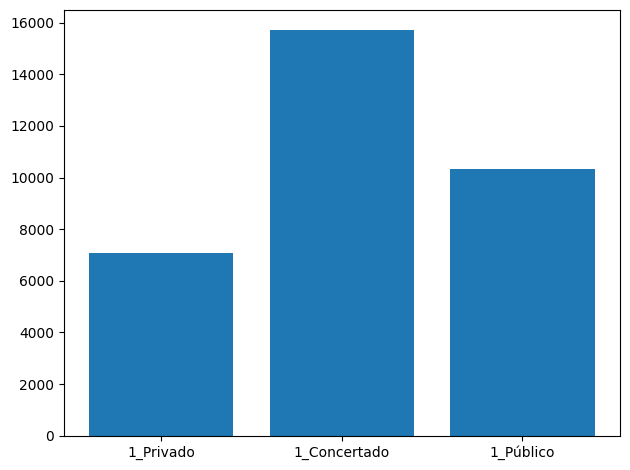

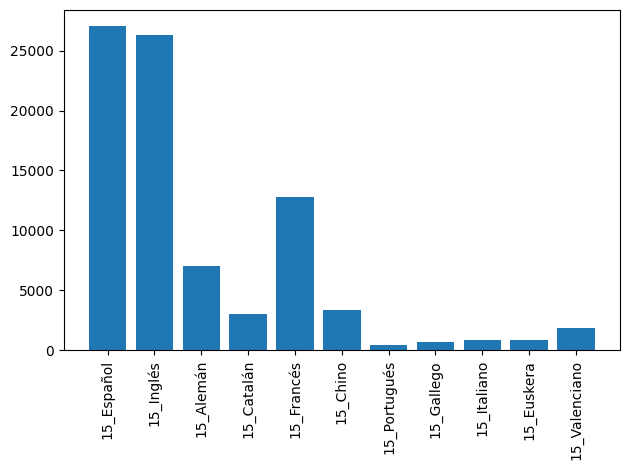

In [13]:
# Save list imagess
columns = ['14_Ed. Infantil 1er ciclo (0-3 años)', '14_Ed. Infantil 2° ciclo (3-6 años)', '14_Primaria', '14_Secundaria', '14_Bachillerato', '14_Otros1']
data = [df_preped[col].sum() for col in columns]
fig, ax = plt.subplots()
ax.bar(columns, data)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f'assets/14_etapas_histogram.png')  # Save the figure

columns = ['1_Privado', '1_Concertado', '1_Público']
data = [df_preped[col].sum() for col in columns]
fig, ax = plt.subplots()
ax.bar(columns, data)
plt.tight_layout()
plt.savefig(f'assets/1_type_histogram.png')  # Save the figure

columns = ['15_Español', '15_Inglés',  '15_Alemán', '15_Catalán', '15_Francés', '15_Chino', 
        '15_Portugués', '15_Gallego', '15_Italiano', '15_Euskera', 
        '15_Valenciano']
data = [df_preped[col].sum() for col in columns]
fig, ax = plt.subplots()
ax.bar(columns, data)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f'assets/15_languages_histogram.png')  # Save the figure


In [148]:
# # Check colinearity with VIF == 15 minutes for id, 3 minutes for user_id
# # drop non-numeric columns if any
# numeric_cols = df_preped.select_dtypes(include=[np.number])

# # For each column, calculate VIF
# vif = pd.DataFrame()
# vif["variables"] = numeric_cols.columns
# vif["VIF"] = [variance_inflation_factor(numeric_cols.values, i) for i in range(numeric_cols.shape[1])]

# pd.set_option('display.max_rows', None)
# vif.sort_values(by='VIF', ascending=False)

### Clustering prep Scaling, PCA, etc

In [71]:
# Scale columns
scaler = StandardScaler(with_std=True,
                        with_mean=True)
df_scaled = scaler.fit_transform(df_preped)
df_scaled = pd.DataFrame(df_scaled)
# df_normalized = normalize(df_scaled)
# df_normalized = pd.DataFrame(df_normalized)

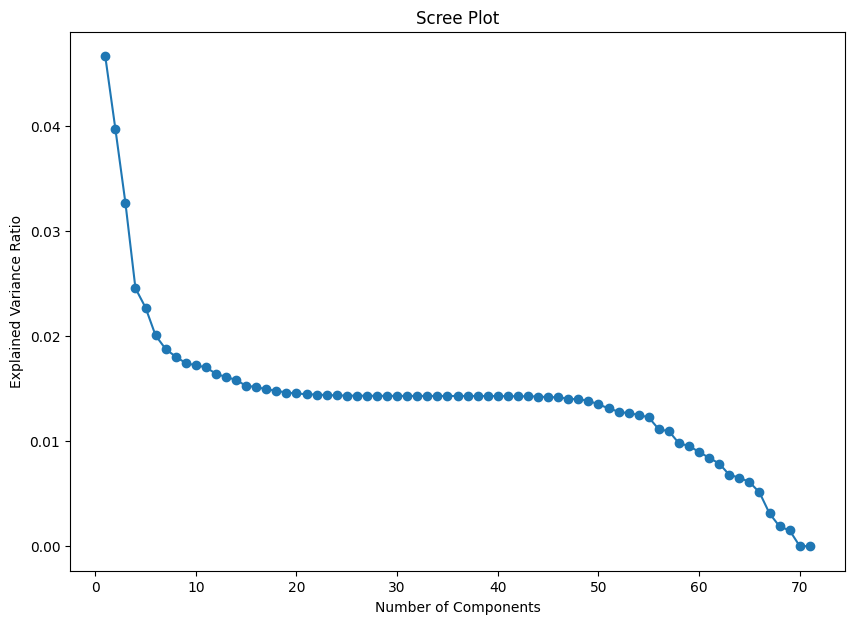

In [74]:
# Get a scree plot for all principal components
pca = PCA()
df_pca = pca.fit_transform(df_scaled)

# Calculate explained variance ratios
explained_variance_ratio = pca.explained_variance_ratio_

# Create scree plot
plt.figure(figsize=(10, 7))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.savefig(f'assets/scree_plot.png')  # Save the figure
# plt.show()

In [75]:
explained_variance_ratio

array([4.65908402e-02, 3.97181155e-02, 3.26707447e-02, 2.45271631e-02,
       2.26955268e-02, 2.00392504e-02, 1.87533944e-02, 1.80210504e-02,
       1.74157453e-02, 1.71984463e-02, 1.70148025e-02, 1.63936918e-02,
       1.60908245e-02, 1.58124102e-02, 1.52414977e-02, 1.51472499e-02,
       1.49087608e-02, 1.47859990e-02, 1.46037131e-02, 1.45354422e-02,
       1.44429843e-02, 1.44257148e-02, 1.43691211e-02, 1.43428301e-02,
       1.43175778e-02, 1.43133419e-02, 1.43070187e-02, 1.42982987e-02,
       1.42964549e-02, 1.42926694e-02, 1.42906232e-02, 1.42903535e-02,
       1.42882136e-02, 1.42866676e-02, 1.42856006e-02, 1.42853983e-02,
       1.42840651e-02, 1.42827676e-02, 1.42793699e-02, 1.42777034e-02,
       1.42657179e-02, 1.42572401e-02, 1.42513155e-02, 1.42338156e-02,
       1.41721813e-02, 1.41625550e-02, 1.40164653e-02, 1.39749334e-02,
       1.38371543e-02, 1.34843372e-02, 1.31195028e-02, 1.27883676e-02,
       1.26424260e-02, 1.24922165e-02, 1.22453793e-02, 1.11134033e-02,
      

In [104]:
# Get the feature loadings
pca = PCA(n_components=4) #41-46 for users
df_pca = pca.fit_transform(df_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
loadings = pca.components_
df_loadings = pd.DataFrame()

for i,loading in enumerate(loadings):
    pc_loading_raw = {}
    pc_loading = {}
    for j, loading in enumerate(loading):
        pc_loading_raw[df_preped.columns[j]] = round(loading, 1)
        pc_loading[df_preped.columns[j]] = (loading**2)
    df_loadings[i] = pc_loading
    df_loadings[f'{i}_raw'] = pc_loading_raw
    df_loadings[i] = round(np.sqrt(df_loadings[i] * 1000000) * explained_variance_ratio[i], 2)

In [114]:
pd.set_option('display.max_rows', None)
df_loadings.sort_values(by=3, ascending=False)

,0,0_raw,1,1_raw,2,2_raw,3,3_raw
19_Año que viene,2.10,-0.0,4.82,-0.1,1.67,0.1,14.63,-0.6
19_Este año,4.18,-0.1,6.42,0.2,0.90,-0.0,14.52,0.6
5_extraescolares,2.35,0.1,9.80,-0.2,6.29,-0.2,4.79,0.2
6_techImportancia,1.91,0.0,6.70,-0.2,3.02,0.1,4.71,0.2
1_Concertado,1.03,0.0,5.64,-0.1,0.66,-0.0,4.44,0.2
8_resultAcademicosImportancia,2.60,0.1,9.00,-0.2,2.25,0.1,4.33,0.2
12_Entre 30 y 40,2.30,-0.0,3.30,-0.1,15.30,-0.5,3.74,-0.2
9_precioComun,3.21,0.1,10.00,-0.3,5.51,0.2,3.64,-0.1
2_religioso,1.76,0.0,7.51,-0.2,2.62,0.1,3.18,0.1
1_Público,3.05,-0.1,8.84,0.2,4.44,-0.1,3.16,0.1


In [111]:
# # check cluster SSE
# sse = []
# list_k = list(range(1, 30))

# for k in list_k:
#     km = KMeans(n_clusters=k)
#     km.fit(df_pca)
#     sse.append(km.inertia_)

# # Plot sse against k
# plt.figure(figsize=(6, 6))
# plt.plot(list_k, sse, '-o')
# plt.xlabel('Number of clusters k')
# plt.ylabel('Sum of squared distance')

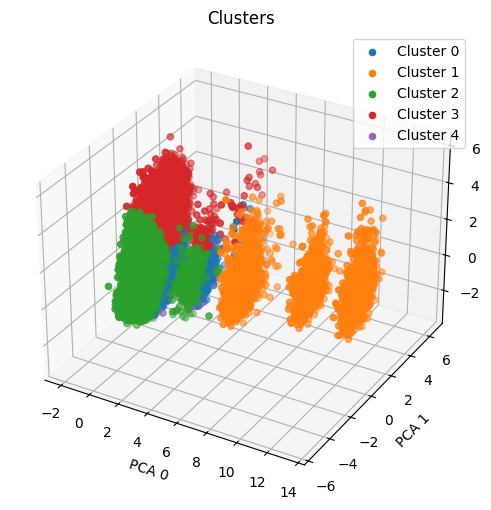

In [112]:
# Plot 3d
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

x = 0
y = 1
z = 2

# Assuming that df_pca is a 3D array for simplicity
for i in range(k3_pca_3.n_clusters):
    ax.scatter(df_pca[labels == i, x], df_pca[labels == i, y], df_pca[labels == i, z], label='Cluster {}'.format(i))

ax.set_title('Clusters')
ax.set_xlabel(f'PCA {x}')
ax.set_ylabel(f'PCA {y}')
ax.set_zlabel(f'PCA {z}')
ax.legend()
plt.show()

In [88]:
kmeans = KMeans(n_clusters=5, random_state=42) 
k3_pca_3 = kmeans.fit(df_pca)

# The cluster labels for each instance are now stored in kmeans.labels_
labels = kmeans.labels_

# You can also get the coordinates of the cluster centroids
centroids = kmeans.cluster_centers_
np.round(centroids, 4)

c:\Users\Alex\Documents\testing\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([[-0.5924,  0.7513, -0.7852,  1.3906],
       [ 8.1643,  2.1194, -0.3362, -0.0556],
       [ 0.2996, -1.9996,  0.1203, -0.0294],
       [-0.5392,  0.9966,  2.2382, -0.1318],
       [-0.5866,  0.4974, -0.9363, -1.205 ]])

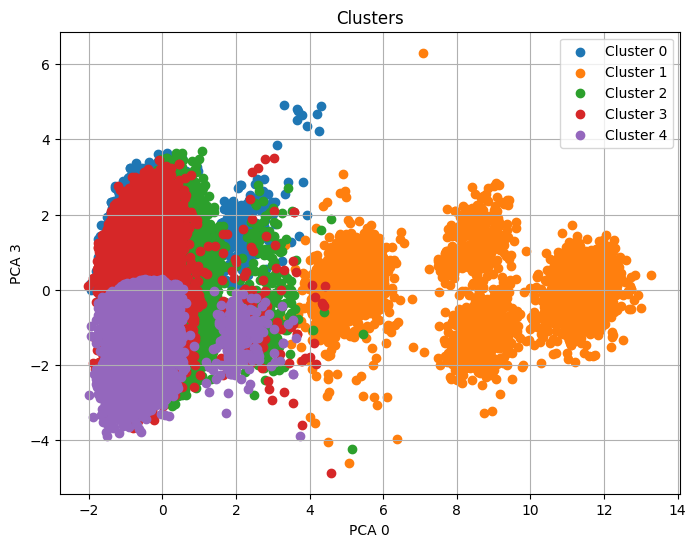

In [94]:
# Assuming that df_pca is a 2D array for simplicity
plt.figure(figsize=(8, 6))

x = 0
y = 3

# Scatter plot of the data points
for i in range(k3_pca_3.n_clusters):
    plt.scatter(df_pca[labels == i, x], df_pca[labels == i, y], label='Cluster {}'.format(i))

# # Plotting centroids
# plt.scatter(centroids[:, 1], centroids[:, 1], s=300, c='red', label='Centroids')

plt.title('Clusters')
plt.xlabel(f'PCA {x}')
plt.ylabel(f'PCA {y}')
plt.legend()
plt.grid(True)
plt.show()


In [165]:
centroids # Rich city older religious users, men and women  # Cheap urgent middle-aged women with few young kids  # Middle class older women with several teenage/young kids

array([[-1.38823752e+00, -3.37590366e-02, -6.31834951e-02,
         1.84160444e-02,  4.37212944e-02,  7.79141797e-02,
         2.69613266e-02,  4.65770307e-03],
       [ 1.49459845e+00,  3.14268601e-02,  3.09902516e-03,
        -3.04760932e-02, -4.72309749e-02, -8.58663252e-02,
        -2.77091574e-02, -5.41945023e-03],
       [-1.92346456e+00,  4.61741926e+00,  6.14789772e+01,
         1.01236922e+01,  2.12242112e-01,  1.98807062e+00,
        -1.21230088e+00,  3.90400469e-01]])

In [166]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Compute the correlation-based distance matrix
corr_dist = pdist(df_pca, metric='correlation')

# Perform hierarchical clustering using the correlation-based distance matrix
linkage_matrix = linkage(corr_dist, method='complete')

# Plot the dendrogram
dendrogram(linkage_matrix)
plt.show()

In [49]:
# plt.figure(figsize =(8, 8))
# plt.title('Visualising the data')
# Dendrogram = shc.dendrogram((shc.linkage(data_principal, method ='ward')))

In [21]:
# HClust = AgglomerativeClustering
# hc_comp = HClust(distance_threshold=0,
#                  n_clusters=None,
#                  linkage='complete')
# hc_comp.fit(df_normalized)


In [ ]:
# hc_cor = HClust(distance_threshold=0,
#                 n_clusters=None,
#                 linkage='average');
# hc_cor.fit(df_scaled)

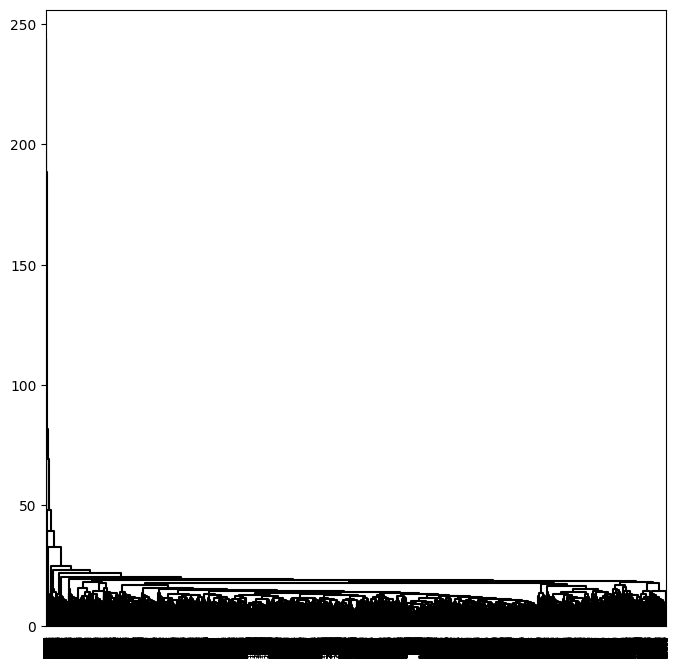

In [24]:
# cargs = {'color_threshold':-np.inf,
#          'above_threshold_color':'black'}
# linkage_comp = compute_linkage(hc_comp)
# fig, ax = plt.subplots(1, 1, figsize=(80, 80))
# dendrogram(linkage_comp,
#            ax=ax,
#            **cargs);


In [25]:
# fig, ax = plt.subplots(1, 1, figsize=(80, 80))
# dendrogram(linkage_comp,
#            ax=ax,
#            color_threshold=4,
#            above_threshold_color='black');

Error in callback <function flush_figures at 0x00000197EBE62D40> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# cut_tree(linkage_comp, n_clusters=4).T

In [ ]:
# cut_tree(linkage_comp, height=5)
